# Interval unfolding with intvalpy (`unfold_interval_intvalpy`)

This notebook applies the interval unfolding method using the
[intvalpy](https://pypi.org/project/intvalpy/) package to the IAEA
Compendium benchmark spectrum:

> S. P. Shary, *Interval methods for regularization of ill-conditioned
> and incorrectly posed problems*, XVIII All-Russian Conference of
> Young Scientists, 2017.

The method computes guaranteed bounds on the neutron spectrum by
maximizing the recognizing functional Tol(x) using `intvalpy.Tol.maximize`,
then computes bounds using LP for each variable. If the tolerance set
is empty (`tol_max < 0`), the pseudo-solution is used as the best
approximation (following the literature).

Two methods are supported:
* **rohn** (default): Rohn's method for overdetermined systems
* **shary**: Shary's method for general interval systems


In [1]:
# %pip install bssunfold pandas numpy matplotlib intvalpy

## 1. Detector response functions

We use the built-in GSF response functions (10 Bonner spheres, `0in` -
`18in`, 60 energy bins from 1e-9 to ~631 MeV).


Detector grid: 60 bins, 1.0e-09 - 631.0 MeV
Spheres: 0in, 2in, 3in, 5in, 6in, 8in, 10in, 12in, 15in, 18in


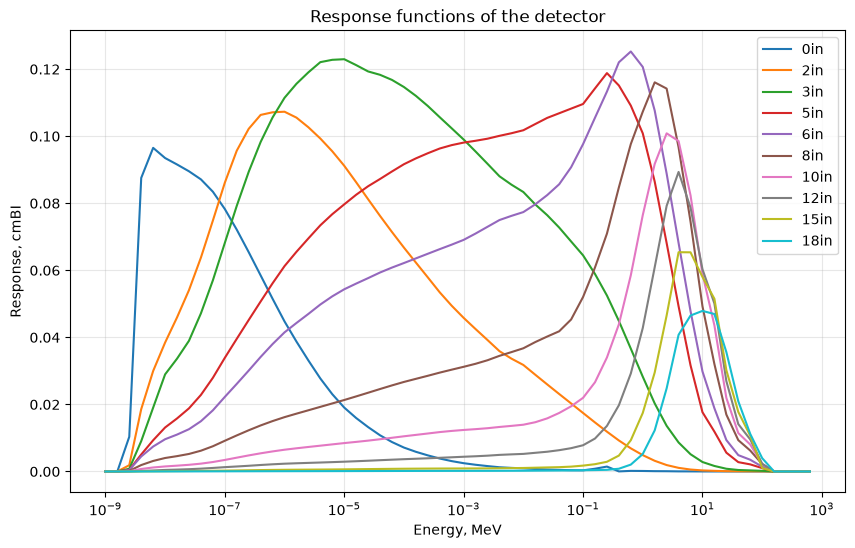

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bssunfold import Detector, RF_GSF
from bssunfold.utils.comparison import compare_spectra

detector = Detector(RF_GSF)
E = detector.E_MeV
names = detector.detector_names
print(f"Detector grid: {detector.n_energy_bins} bins, "
      f"{E[0]:.1e} - {E[-1]:.1f} MeV")
print("Spheres:", ", ".join(names))
detector.plot_response_functions()

## 2. IAEA Compendium reference spectrum -> detector readings

The compendium CSV stores 61-point Monte-Carlo spectra on its own energy
grid, which differs slightly from the 60-bin detector grid, so the
ground truth is interpolated onto the detector grid *for evaluation
only*.  The readings are the spectrum folded with the response
functions.


In [3]:
reference_csv = pd.read_csv(
    '../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv'
)
print(f"Reference CSV: {len(reference_csv)} rows, "
      f"{len(reference_csv.columns) - 1} spectra, "
      f"{reference_csv['E_MeV'].min():.1e} - "
      f"{reference_csv['E_MeV'].max():.0f} MeV")

SPECTRUM = 't4-14-s.txt_1'   # IAEA Compendium BSA benchmark case

readings = detector.get_effective_readings_for_spectra(
    reference_csv[['E_MeV', SPECTRUM]]
)
print("Effective readings:")
for name, val in readings.items():
    print(f"  {name:>4s}: {val:.4f}")

# Interpolate ground truth onto detector grid for evaluation
phi_true = np.interp(
    E, reference_csv['E_MeV'], reference_csv[SPECTRUM]
)

# Active energy bins for plotting
Emax = 20.0
active = E <= Emax
E_active = E[active]
phi_true_active = phi_true[active]

Reference CSV: 61 rows, 20 spectra, 1.0e-09 - 631 MeV
Effective readings:
   0in: 0.0668
   2in: 0.0901
   3in: 0.1382
   5in: 0.1639
   6in: 0.1407
   8in: 0.0805
  10in: 0.0392
  12in: 0.0179
  15in: 0.0064
  18in: 0.0031


## 3. Unfold with intvalpy interval analysis

Two methods are demonstrated:

* **rohn** (default): Rohn's method for overdetermined systems
* **shary**: Shary's method for general interval systems

The energy cutoff `max_neutron_energy=20.0` confines the solution to
the range covered by the benchmark spectrum.


In [4]:
result_rohn = detector.unfold_interval_intvalpy(
    readings,
    noise_level=0.1,
    max_neutron_energy=20.0,
    method="rohn",
    save_result=False,
)

result_shary = detector.unfold_interval_intvalpy(
    readings,
    noise_level=0.1,
    max_neutron_energy=20.0,
    method="shary",
    save_result=False,
)

result_norm = detector.unfold_interval_intvalpy(
    readings,
    noise_level=0.1,
    max_neutron_energy=20.0,
    method="rohn",
    normalize=True,
    save_result=False,
)

result_reg = detector.unfold_interval_intvalpy(
    readings,
    noise_level=0.1,
    max_neutron_energy=20.0,
    method="rohn",
    regularization=0.1,
    save_result=False,
)

for label, result in [("rohn", result_rohn), ("shary", result_shary),
                      ("rohn+norm", result_norm), ("rohn+reg", result_reg)]:
    print(f"\n{label}:")
    print(f"  method        : {result['method']}")
    print(f"  tol_max       : {result['tol_max']:.4f}")
    print(f"  n_iter        : {result['n_iter']}")
    print(f"  n_calls       : {result['n_calls']}")
    print(f"  exit_code     : {result['exit_code']}")
    print(f"  interval width: {np.sum(result['spectrum_upper'] - result['spectrum_lower']):.4f}")
    print(f"  sum spectrum  : {np.sum(result['spectrum']):.4f}")


rohn:
  method        : IntervalIntvalpy
  tol_max       : 0.0003
  n_iter        : 29
  n_calls       : 45
  exit_code     : 1
  interval width: 53.2026

shary:
  method        : IntervalIntvalpy
  tol_max       : 0.0003
  n_iter        : 29
  n_calls       : 45
  exit_code     : 1
  interval width: 53.2026


## 4. Method comparison

The `rohn` and `shary` methods may produce different bounds and
pseudo-solutions. This section compares their performance.


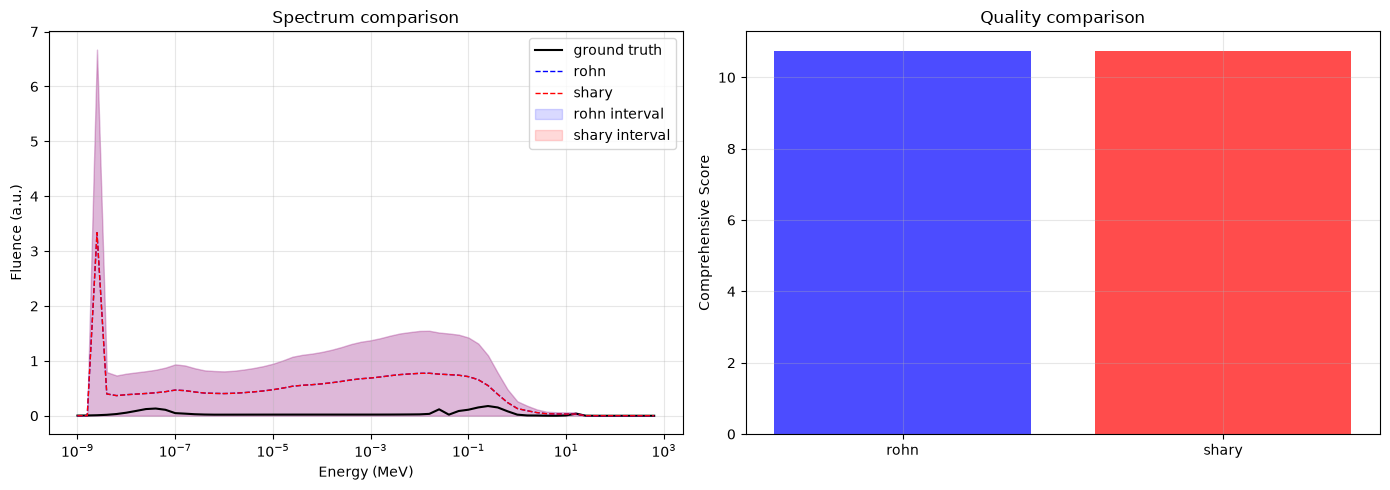

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(E, phi_true, "k-", lw=1.5, label="ground truth")
axes[0].plot(E, result_rohn["spectrum"], "b--", lw=1, label="rohn")
axes[0].plot(E, result_shary["spectrum"], "r--", lw=1, label="shary")
axes[0].plot(E, result_norm["spectrum"], "g--", lw=1, label="rohn+norm")
axes[0].plot(E, result_reg["spectrum"], "m--", lw=1, label="rohn+reg")
axes[0].fill_between(E, result_rohn["spectrum_lower"], result_rohn["spectrum_upper"],
                    color="blue", alpha=0.15, label="rohn interval")
axes[0].set_xlabel("Energy (MeV)")
axes[0].set_xscale('log')
axes[0].set_ylabel("Fluence (a.u.)")
axes[0].set_title("Spectrum comparison")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

metrics_rohn = compare_spectra(phi_true, result_rohn["spectrum"],
                                metrics=["comprehensive_score"])
metrics_shary = compare_spectra(phi_true, result_shary["spectrum"],
                                 metrics=["comprehensive_score"])
metrics_norm = compare_spectra(phi_true, result_norm["spectrum"],
                                metrics=["comprehensive_score"])
metrics_reg = compare_spectra(phi_true, result_reg["spectrum"],
                               metrics=["comprehensive_score"])

axes[1].bar([0, 1, 2, 3], [metrics_rohn["comprehensive_score"],
                   metrics_shary["comprehensive_score"],
                   metrics_norm["comprehensive_score"],
                   metrics_reg["comprehensive_score"]],
           color=["blue", "red", "green", "magenta"], alpha=0.7)
axes[1].set_xticks([0, 1, 2, 3])
axes[1].set_xticklabels(["rohn", "shary", "rohn+norm", "rohn+reg"])
axes[1].set_ylabel("Comprehensive Score")
axes[1].set_title("Quality comparison")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Empty tolerance set handling

When the tolerance set is empty (`tol_max < 0`), the method uses
the pseudo-solution as the best approximation. This section
demonstrates this behavior with a very narrow noise level.


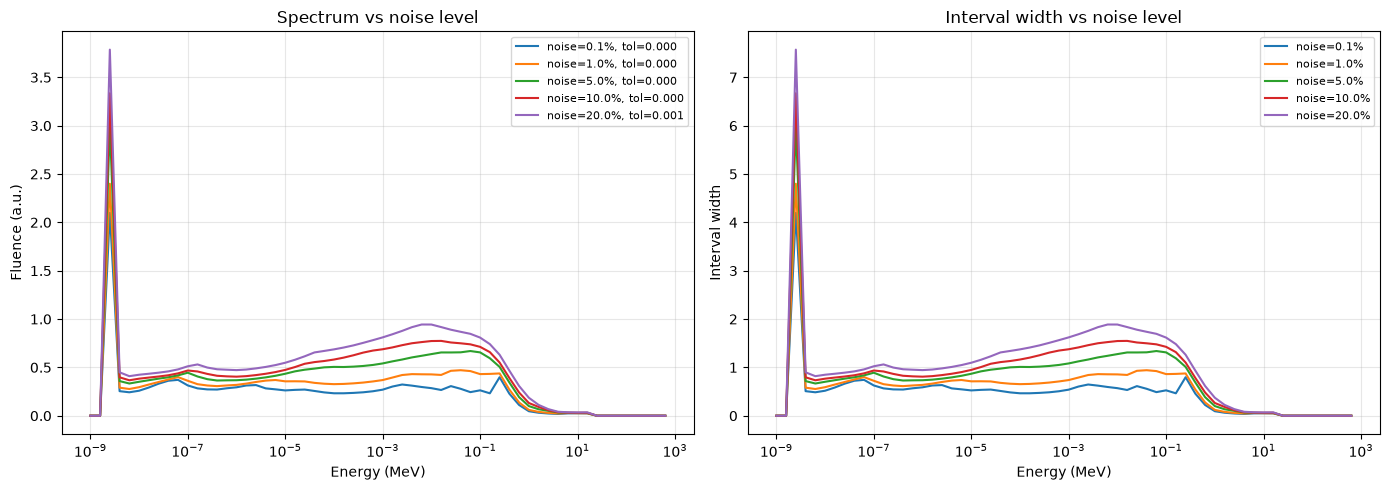

In [9]:
noise_levels = [0.001, 0.01, 0.05, 0.1, 0.2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nl in noise_levels:
    res = detector.unfold_interval_intvalpy(
        readings, noise_level=nl, max_neutron_energy=20.0, method="rohn",
    )
    axes[0].semilogx(E, res["spectrum"], label=f"noise={nl:.1%}, tol={res['tol_max']:.3f}")
    axes[1].semilogx(E, res["spectrum_upper"] - res["spectrum_lower"],
                    label=f"noise={nl:.1%}")

axes[0].set_xlabel("Energy (MeV)")
axes[0].set_ylabel("Fluence (a.u.)")
axes[0].set_title("Spectrum vs noise level")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Energy (MeV)")
axes[1].set_ylabel("Interval width")
axes[1].set_title("Interval width vs noise level")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Baselines

Two widely used iterative baselines — **GRAVEL** (weighted log-domain
least squares) and **MLEM** — start from the same flat prior for
comparison.


method                          score
--------------------------------------
Interval intvalpy (rohn)       10.752
Interval intvalpy (shary)      10.752
GRAVEL                          2.954
MLEM                            1.519


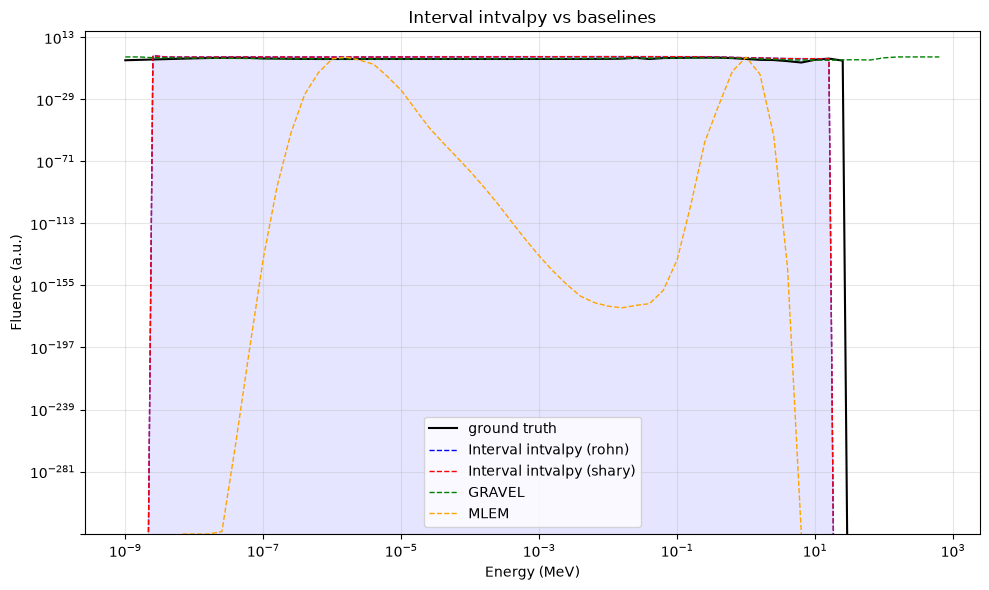

In [7]:
grav = detector.unfold_gravel(
    readings,
    initial_spectrum=np.full(E.size, 0.5),
    max_iterations=2000,
    save_result=False,
)
mlem = detector.unfold_mlem(
    readings,
    initial_spectrum=np.full(E.size, 0.5),
    max_iterations=2000,
    save_result=False,
)

labels = ["Interval intvalpy (rohn)", "Interval intvalpy (shary)", "GRAVEL", "MLEM"]
spectra = [result_rohn["spectrum"], result_shary["spectrum"],
           grav["spectrum"], mlem["spectrum"]]
print(f"{'method':<28s} {'score':>8s}")
print("-" * 38)
for label, spec in zip(labels, spectra):
    m = compare_spectra(phi_true, spec, metrics=["comprehensive_score"])
    print(f"{label:<28s} {m['comprehensive_score']:>8.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(E, phi_true, "k-", lw=1.5, label="ground truth")
for label, spec, color in zip(labels, spectra,
                                ["blue", "red", "green", "orange"]):
    ax.loglog(E, spec, "--", color=color, lw=1, label=label)
ax.fill_between(E, result_rohn["spectrum_lower"],
                result_rohn["spectrum_upper"],
                color="blue", alpha=0.1)
ax.set_xlabel("Energy (MeV)")
ax.set_ylabel("Fluence (a.u.)")
ax.set_title("Interval intvalpy vs baselines")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Summary

* `unfold_interval_intvalpy` implements interval unfolding using
  the `intvalpy` package: it maximizes the recognizing functional
  `Tol(x)` to find a pseudo-solution, then computes per-bin bounds.
* Two methods are supported: `rohn` (default) and `shary`.
* When the tolerance set is empty (`tol_max < 0`), the
  pseudo-solution is used as the best approximation (following
  the literature).
* **Normalization** (`normalize=True`): scales the spectrum so that
  the total fluence matches the sum of the midpoint readings.
* **Regularization** (`regularization=float`): applies Tikhonov
  regularization to smooth the solution.
* The method returns `tol_max`, `x_pseudo`, `n_iter`, `n_calls`,
  `exit_code`, `intvalpy_method`, `normalize`, and `regularization`
  as additional metadata.
* Requires optional dependency: `pip install "bssunfold[intvalpy]"`.
